# Árboles de Regresión — Demostración Didáctica

Este notebook genera las figuras utilizadas en el capítulo de Marco Teórico para ilustrar el funcionamiento de los árboles de regresión. Se utiliza el dataset *Advertising* (ISLR) con dos features (TV, Radio) para predecir ventas, lo que permite visualizar las particiones del árbol en un plano bidimensional.

Se recorren paso a paso las divisiones del árbol (split raíz, segundo split, tercer split) y se muestran las regiones resultantes. Las figuras se guardan en `Outputs/regression_trees/`.

## Configuración del entorno

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Resolve output directory relative to the repo root
_cwd = Path.cwd()
if (_cwd / "src").exists():
    _code_root = _cwd
elif (_cwd.parent / "src").exists():
    _code_root = _cwd.parent
else:
    _code_root = _cwd

REPO = _code_root.parent
OUT_DIR = str(REPO / "Outputs" / "regression_trees")
os.makedirs(OUT_DIR, exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"

FEATURES = ["TV", "Radio"]
TARGET = "Sales"

N_POINTS = 30
RANDOM_STATE_SUBSET = 7

MAX_DEPTH = 3
MIN_SAMPLES_LEAF = 3


## Carga y selección del dataset

In [2]:
df = pd.read_csv(DATA_URL)
df2 = df[FEATURES + [TARGET]].dropna().copy()

print("Advertising dataset (ISLR):")
print("- TV y Radio = presupuesto de publicidad (miles de USD)")
print("- Sales = ventas (miles de unidades)")
print(f"\nUsamos 2 features (TV, Radio) para predecir {TARGET}.\n")

df2.head()


Advertising dataset (ISLR):
- TV y Radio = presupuesto de publicidad (miles de USD)
- Sales = ventas (miles de unidades)

Usamos 2 features (TV, Radio) para predecir Sales.



,TV,Radio,Sales
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,9.3
3,151.5,41.3,18.5
4,180.8,10.8,12.9


## Subconjunto para demostración visual

Se extrae un subconjunto reducido del dataset completo para facilitar la visualización en dos dimensiones. Este subconjunto se utiliza únicamente con fines ilustrativos para mostrar el proceso de partición del espacio mediante un árbol de regresión.

In [3]:
idx_s = df2.sample(n=N_POINTS, random_state=RANDOM_STATE_SUBSET).index

df_s = df2.loc[idx_s].reset_index(drop=True)

X = df_s[FEATURES].to_numpy()
y = df_s[TARGET].to_numpy()


## Funciones auxiliares

Se definen utilidades para:
 - Calcular SSE y reducciones de SSE asociadas a cortes candidatos.
 - Computar RMSE de forma compatible entre versiones, y
 - Generar y almacenar figuras con un formato consistente para su incorporación posterior en el documento.

In [4]:
def sse(y):
    y = np.asarray(y)
    mu = y.mean() if len(y) else 0.0
    return float(((y - mu) ** 2).sum())


def delta_sse_for_threshold(X, y, feat_idx, thr):
    parent = sse(y)
    mask = X[:, feat_idx] <= thr
    yl, yr = y[mask], y[~mask]
    children = sse(yl) + sse(yr)
    delta = parent - children
    return delta, parent, sse(yl), sse(yr), mask


def rmse_compat(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def save_and_show(filename):
    path = os.path.join(OUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Guardado:", path)


def get_plane_limits(X, pad_frac=0.08):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    pad_x = pad_frac * (x_max - x_min)
    pad_y = pad_frac * (y_max - y_min)
    return x_min, x_max, y_min, y_max, pad_x, pad_y


def draw_vline_segment(x, y_min, y_max, label=None):
    plt.plot([x, x], [y_min, y_max], linestyle="--")
    if label:
        plt.text(x, y_min, label, rotation=90, va="bottom", ha="right", fontsize=9)


def draw_hline_segment(y, x_min, x_max, label=None):
    plt.plot([x_min, x_max], [y, y], linestyle="--")
    if label:
        plt.text(x_min, y, label, va="bottom", ha="left", fontsize=9)


def base_scatter_sales(X, y, title):
    plt.figure(figsize=(7.2, 5.6))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=60)
    plt.colorbar(sc, label="Sales (miles)")
    plt.xlabel("TV (miles USD)")
    plt.ylabel("Radio (miles USD)")
    plt.title(title)
    return sc


## Visualización de los datos crudos

Se genera un scatter plot del subconjunto de datos en el plano TV × Radio, con el color representando el valor de Sales. Esta visualización sirve como referencia para entender las particiones que realizará el árbol.

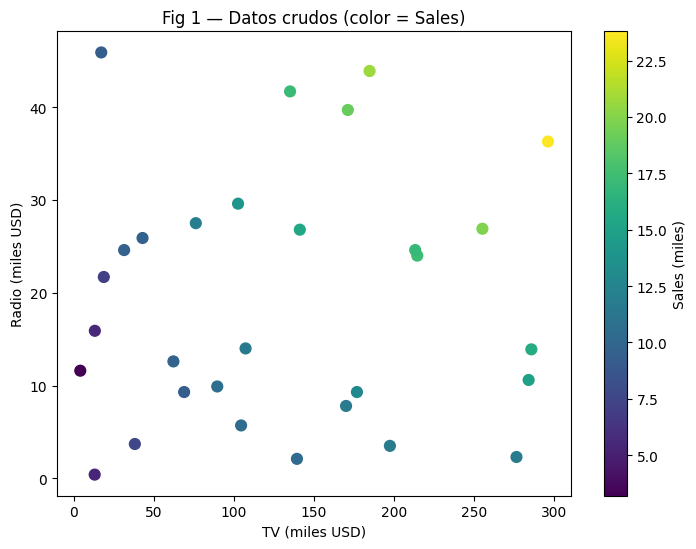

Guardado: fig_tree_advertising_steps_clean/fig1_datos_crudos.png


In [5]:
base_scatter_sales(X, y, "Fig 1 — Datos crudos (color = Sales)")
save_and_show("fig1_datos_crudos.png")

## Entrenamiento del árbol (subconjunto)

Se ajusta un árbol de regresión sobre el subconjunto bidimensional seleccionado. Este modelo se utiliza como referencia para analizar de forma visual y secuencial el proceso de partición del espacio.

In [6]:
tree = DecisionTreeRegressor(
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE_SUBSET
).fit(X, y)

print("depth:", tree.get_depth())
print("leaves:", tree.get_n_leaves())


depth: 3
leaves: 7


## Visualización del árbol completo

Se muestra la estructura completa del árbol entrenado, incluyendo las condiciones de división, la impureza de cada nodo y el valor promedio en las hojas. Esta figura se utiliza como referencia para interpretar los pasos de partición que se analizan posteriormente.

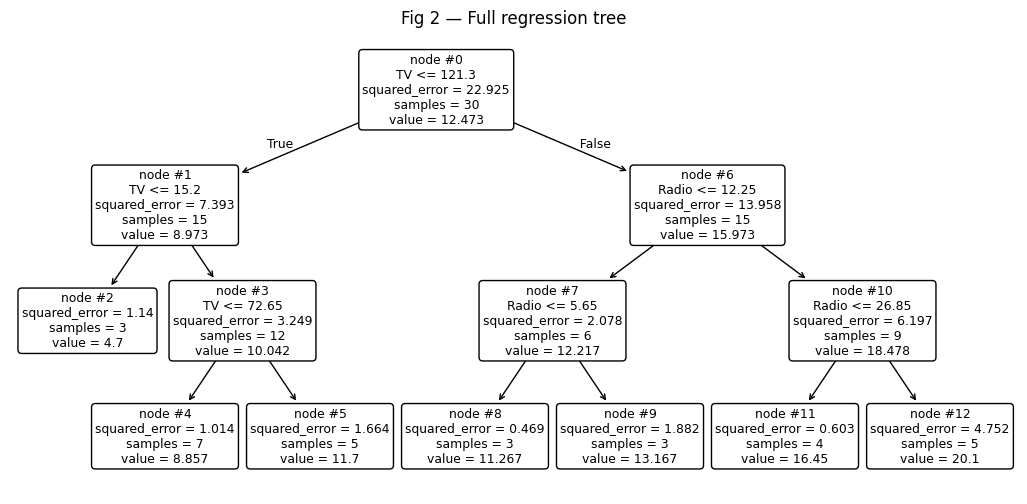

In [7]:
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def color_tree_leaves_with_cmap_norm(tree, node_artists, cmap, norm, alpha=0.85):
    t = tree.tree_
    values = t.value.squeeze()

    for artist in node_artists:
        txt = artist.get_text()
        m = re.search(r"node\s+#(\d+)", txt)
        if not m:
            continue

        node_id = int(m.group(1))
        is_leaf = (t.children_left[node_id] == -1 and t.children_right[node_id] == -1)
        if not is_leaf:
            continue

        bbox = artist.get_bbox_patch()
        if bbox is None:
            continue

        r, g, b, _ = cmap(norm(values[node_id]))
        bbox.set_facecolor((r, g, b, alpha))
        bbox.set_edgecolor("black")

fig2, ax2 = plt.subplots(figsize=(13, 6))

node_artists = plot_tree(
    tree,
    feature_names=FEATURES,
    filled=False,
    rounded=True,
    impurity=True,
    node_ids=True,
    ax=ax2
)

ax2.set_title("Fig 2 — Full regression tree")
plt.show()


## Extracción del split raíz
Se accede a la representación interna del árbol para obtener la variable y el umbral que definen la primera partición del espacio (nodo raíz), que constituye el primer paso del proceso de división.

In [8]:
t = tree.tree_

root_feat = int(t.feature[0])
root_thr  = float(t.threshold[0])
root_name = FEATURES[root_feat]

print("Split raíz REAL:")
print(f"  {root_name} <= {root_thr:.3f}")


Split raíz REAL:
  TV <= 121.300


## Comparación de candidatos en el nodo raíz

Se evalúa la ganancia en reducción de SSE del split elegido por el árbol en el nodo raíz y se la compara con el mejor split posible sobre la otra variable, con el fin de ilustrar el criterio de selección basado en maximizar la reducción de impureza.

In [9]:
delta_root, parent_sse, left_sse, right_sse, mask_root = delta_sse_for_threshold(X, y, root_feat, root_thr)

alt_feat = 1 - root_feat
alt_name = FEATURES[alt_feat]

best_alt_delta = -1e18
best_alt_thr = None

for thr in np.unique(X[:, alt_feat]):
    d, _, _, _, _ = delta_sse_for_threshold(X, y, alt_feat, float(thr))
    if d > best_alt_delta:
        best_alt_delta = d
        best_alt_thr = float(thr)

print("Root comparison:")
print(f"- Split choose by the tree: {root_name} <= {root_thr:.3f}  | ΔSSE = {delta_root:.3f}")
print(f"- Best alternative: {alt_name} <= {best_alt_thr:.3f} | ΔSSE = {best_alt_delta:.3f}")


Root comparison:
- Split choose by the tree: TV <= 121.300  | ΔSSE = 367.500
- Best alternative: Radio <= 21.700 | ΔSSE = 246.888


## Proyección del split raíz en el plano

Se representa el primer corte del árbol sobre el espacio bidimensional (TV, Radio), manteniendo el valor real de la variable objetivo como escala de color y diferenciando ambas ramas mediante contornos, para facilitar la lectura del particionado inducido por el nodo raíz.

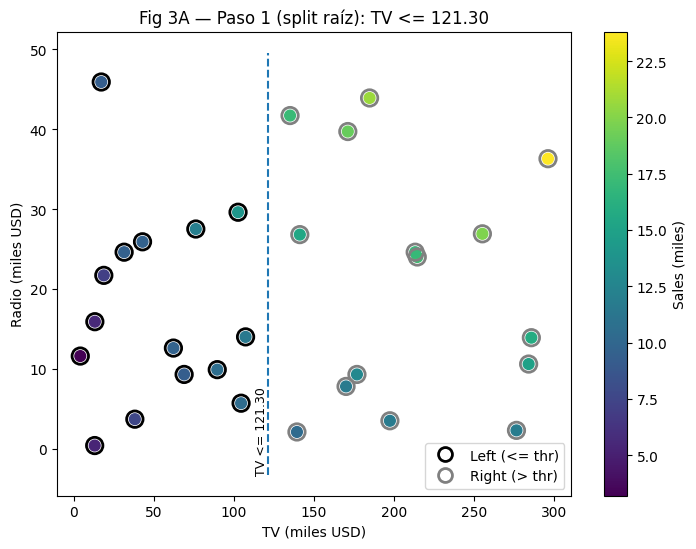

Guardado: fig_tree_advertising_steps_clean/fig3A_paso1_split_raiz.png


In [10]:
x_min, x_max, y_min, y_max, pad_x, pad_y = get_plane_limits(X)

base_scatter_sales(X, y, f"Fig 3A — Paso 1 (split raíz): {root_name} <= {root_thr:.2f}")

mask_root = (X[:, root_feat] <= root_thr)

plt.scatter(
    X[mask_root, 0], X[mask_root, 1],
    facecolors="none", edgecolors="black",
    linewidths=2.0, s=140
)
plt.scatter(
    X[~mask_root, 0], X[~mask_root, 1],
    facecolors="none", edgecolors="gray",
    linewidths=2.0, s=140
)

if root_feat == 0:
    draw_vline_segment(root_thr, y_min - pad_y, y_max + pad_y, label=f"{root_name} <= {root_thr:.2f}")
else:
    draw_hline_segment(root_thr, x_min - pad_x, x_max + pad_x, label=f"{root_name} <= {root_thr:.2f}")

legend_elems = [
    Line2D([0], [0], marker="o", color="w", label="Left (<= thr)",
           markerfacecolor="none", markeredgecolor="black", markersize=10, markeredgewidth=2),
    Line2D([0], [0], marker="o", color="w", label="Right (> thr)",
           markerfacecolor="none", markeredgecolor="gray", markersize=10, markeredgewidth=2),
]
plt.legend(handles=legend_elems, loc="lower right")

save_and_show("fig3A_paso1_split_raiz.png")


## Comparación cuantitativa de splits en el nodo raíz

Se resume en una tabla la reducción de SSE del split seleccionado por el árbol frente al mejor split alternativo en la otra variable, de modo de respaldar cuantitativamente la elección realizada en el nodo raíz.

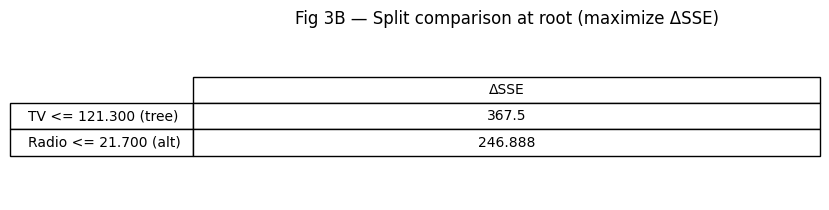

Guardado: fig_tree_advertising_steps_clean/fig3B_tabla_root_vs_alt.png


In [11]:
tbl = pd.DataFrame([
    {"Split": f"{root_name} <= {root_thr:.3f} (tree)", "ΔSSE": delta_root},
    {"Split": f"{alt_name} <= {best_alt_thr:.3f} (alt)", "ΔSSE": best_alt_delta},
]).sort_values("ΔSSE", ascending=False)

plt.figure(figsize=(8.4, 2.2))
plt.axis("off")
tshow = plt.table(
    cellText=np.round(tbl[["ΔSSE"]].to_numpy(), 3),
    rowLabels=tbl["Split"].tolist(),
    colLabels=["ΔSSE"],
    cellLoc="center",
    colLoc="center",
    loc="center"
)
tshow.scale(1, 1.6)
plt.title("Fig 3B — Split comparison at root (maximize ΔSSE)")
save_and_show("fig3B_tabla_root_vs_alt.png")


## Selección del segundo split (rama dominante)

Se identifica el nodo hijo del raíz con mayor número de observaciones y se extrae el split correspondiente. Esta elección permite mostrar una secuencia de particiones sobre la región más representativa del subconjunto.

In [12]:
left_id = int(t.children_left[0])
right_id = int(t.children_right[0])

n_left = int(t.n_node_samples[left_id])
n_right = int(t.n_node_samples[right_id])

go_left_step1 = (n_left >= n_right)
node_step2 = left_id if go_left_step1 else right_id

feat2 = int(t.feature[node_step2])
thr2 = float(t.threshold[node_step2])

print("Step 2: dominant child branch from root")
print("  branch:", "LEFT" if go_left_step1 else "RIGHT")
print("  split:", FEATURES[feat2], "<=", thr2)


Step 2: dominant child branch from root
  branch: LEFT
  split: TV <= 15.200000286102295


## Proyección acumulada hasta el segundo split

Se visualiza el segundo split sobre el plano (TV, Radio) preservando el valor observado de Sales como escala de color. El split previo (raíz) se mantiene como referencia y se distinguen las subramas resultantes dentro de la rama dominante seleccionada.

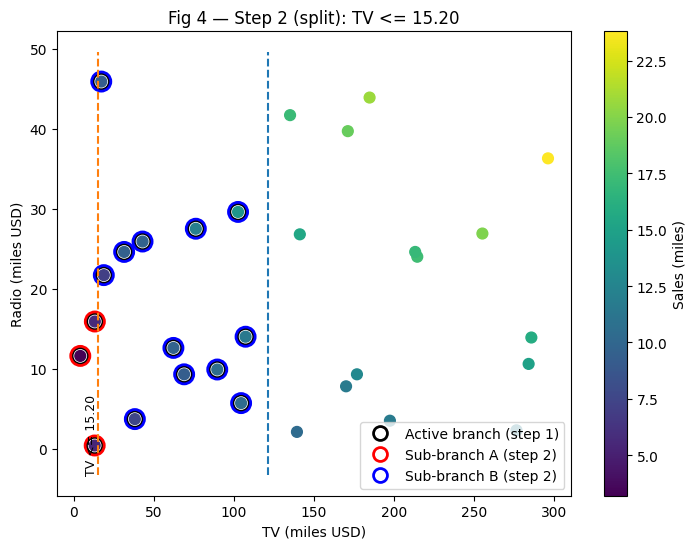

Guardado: fig_tree_advertising_steps_clean/fig4_paso2_split_acumulado.png


In [13]:
mask_step2 = mask_root if go_left_step1 else ~mask_root

mask2_local = np.zeros(len(X), dtype=bool)
mask2_local[mask_step2] = (X[mask_step2, feat2] <= thr2)

base_scatter_sales(X, y, f"Fig 4 — Step 2 (split): {FEATURES[feat2]} <= {thr2:.2f}")

plt.scatter(
    X[mask_step2, 0], X[mask_step2, 1],
    facecolors="none", edgecolors="black",
    linewidths=2.0, s=140
)

plt.scatter(
    X[mask2_local, 0], X[mask2_local, 1],
    facecolors="none", edgecolors="red",
    linewidths=2.0, s=190
)
plt.scatter(
    X[mask_step2 & ~mask2_local, 0], X[mask_step2 & ~mask2_local, 1],
    facecolors="none", edgecolors="blue",
    linewidths=2.0, s=190
)

if root_feat == 0:
    draw_vline_segment(root_thr, y_min - pad_y, y_max + pad_y)
else:
    draw_hline_segment(root_thr, x_min - pad_x, x_max + pad_x)

if feat2 == 0:
    draw_vline_segment(thr2, y_min - pad_y, y_max + pad_y, label=f"{FEATURES[feat2]} <= {thr2:.2f}")
else:
    draw_hline_segment(thr2, x_min - pad_x, x_max + pad_x, label=f"{FEATURES[feat2]} <= {thr2:.2f}")

legend_elems = [
    Line2D([0], [0], marker="o", color="w", label="Active branch (step 1)",
           markerfacecolor="none", markeredgecolor="black", markersize=10, markeredgewidth=2),
    Line2D([0], [0], marker="o", color="w", label="Sub-branch A (step 2)",
           markerfacecolor="none", markeredgecolor="red", markersize=10, markeredgewidth=2),
    Line2D([0], [0], marker="o", color="w", label="Sub-branch B (step 2)",
           markerfacecolor="none", markeredgecolor="blue", markersize=10, markeredgewidth=2),
]
plt.legend(handles=legend_elems, loc="lower right")

save_and_show("fig4_paso2_split_acumulado.png")


## Selección del tercer split (continuación sobre la rama dominante)

Se toma el nodo seleccionado en el paso anterior y, si no es hoja, se escoge su hijo con mayor número de observaciones para extraer el siguiente split. Esto permite continuar la secuencia de particiones sobre la región con mayor soporte empírico dentro del subconjunto.

In [14]:
left2 = int(t.children_left[node_step2])
right2 = int(t.children_right[node_step2])

if left2 == -1 or right2 == -1:
    print("Step 2 node is a leaf under current constraints.")
    node_step3 = None
else:
    n_left2 = int(t.n_node_samples[left2])
    n_right2 = int(t.n_node_samples[right2])

    go_left_step2 = (n_left2 >= n_right2)
    node_step3 = left2 if go_left_step2 else right2

    feat3 = int(t.feature[node_step3])
    thr3 = float(t.threshold[node_step3])

    print("Step 3: dominant child branch within step 2")
    print("  split:", FEATURES[feat3], "<=", thr3)

Step 3: dominant child branch within step 2
  split: TV <= 72.6500015258789


## Proyección acumulada hasta el tercer split

Se extiende la visualización anterior incorporando el tercer split sobre la rama dominante. Se mantienen visibles los cortes previos para reflejar la construcción incremental del particionado, y se distinguen las dos subramas generadas en el tercer paso dentro de la región activa.

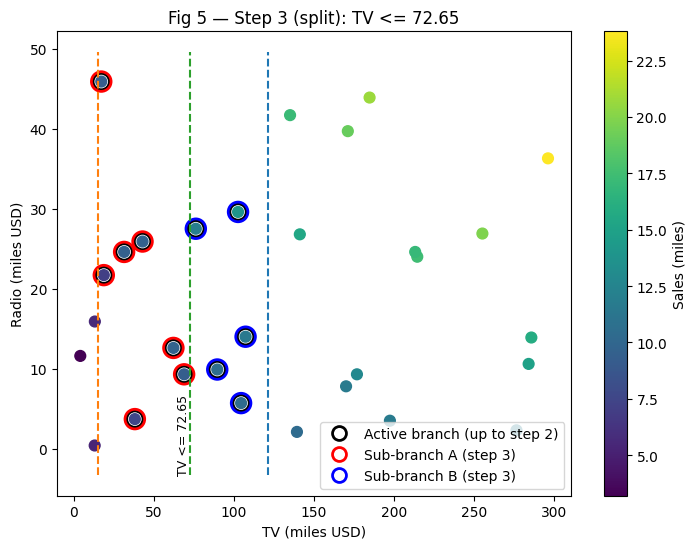

Guardado: fig_tree_advertising_steps_clean/fig5_paso3_split_acumulado.png


In [15]:
if node_step3 is None:
    print("Step 3 not available under current constraints.")
else:
    if go_left_step2:
        mask_step3 = mask2_local
    else:
        mask_step3 = (mask_step2 & ~mask2_local)

    mask3_local = np.zeros(len(X), dtype=bool)
    mask3_local[mask_step3] = (X[mask_step3, feat3] <= thr3)

    base_scatter_sales(X, y, f"Fig 5 — Step 3 (split): {FEATURES[feat3]} <= {thr3:.2f}")

    plt.scatter(
        X[mask_step3, 0], X[mask_step3, 1],
        facecolors="none", edgecolors="black",
        linewidths=2.0, s=140
    )

    plt.scatter(
        X[mask3_local, 0], X[mask3_local, 1],
        facecolors="none", edgecolors="red",
        linewidths=2.0, s=200
    )
    plt.scatter(
        X[mask_step3 & ~mask3_local, 0], X[mask_step3 & ~mask3_local, 1],
        facecolors="none", edgecolors="blue",
        linewidths=2.0, s=200
    )

    if root_feat == 0:
        draw_vline_segment(root_thr, y_min - pad_y, y_max + pad_y)
    else:
        draw_hline_segment(root_thr, x_min - pad_x, x_max + pad_x)

    if feat2 == 0:
        draw_vline_segment(thr2, y_min - pad_y, y_max + pad_y)
    else:
        draw_hline_segment(thr2, x_min - pad_x, x_max + pad_x)

    if feat3 == 0:
        draw_vline_segment(thr3, y_min - pad_y, y_max + pad_y, label=f"{FEATURES[feat3]} <= {thr3:.2f}")
    else:
        draw_hline_segment(thr3, x_min - pad_x, x_max + pad_x, label=f"{FEATURES[feat3]} <= {thr3:.2f}")

    legend_elems = [
        Line2D([0], [0], marker="o", color="w", label="Active branch (up to step 2)",
               markerfacecolor="none", markeredgecolor="black", markersize=10, markeredgewidth=2),
        Line2D([0], [0], marker="o", color="w", label="Sub-branch A (step 3)",
               markerfacecolor="none", markeredgecolor="red", markersize=10, markeredgewidth=2),
        Line2D([0], [0], marker="o", color="w", label="Sub-branch B (step 3)",
               markerfacecolor="none", markeredgecolor="blue", markersize=10, markeredgewidth=2),
    ]
    plt.legend(handles=legend_elems, loc="lower right")

    save_and_show("fig5_paso3_split_acumulado.png")


## Regiones finales inducidas por el árbol

Se representa el particionado final del plano (TV, Radio) inducido por el árbol entrenado. El fondo muestra la predicción constante asignada por cada hoja, y los puntos observados se superponen con color asociado a los valores reales de Sales.

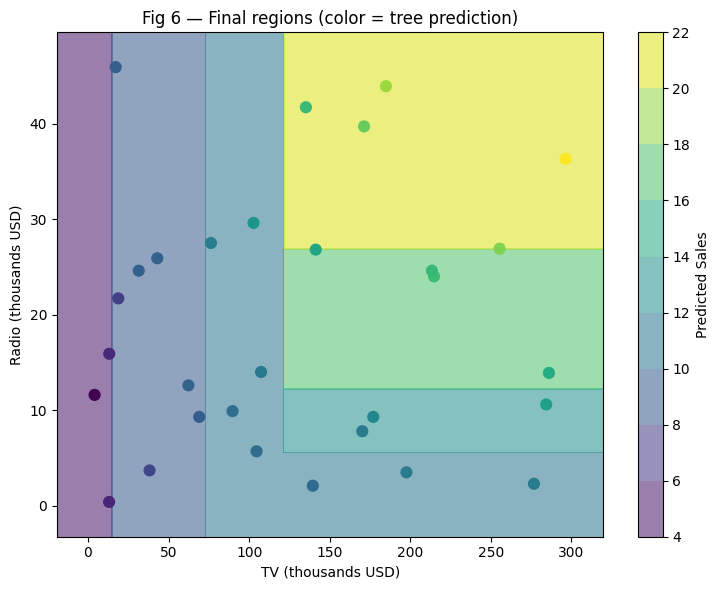

Guardado: fig_tree_advertising_steps_clean/fig6_regiones_finales.png


<Figure size 640x480 with 0 Axes>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors

x_min, x_max, y_min, y_max, pad_x, pad_y = get_plane_limits(X)

xx, yy = np.meshgrid(
    np.linspace(x_min - pad_x, x_max + pad_x, 600),
    np.linspace(y_min - pad_y, y_max + pad_y, 600)
)
grid = np.c_[xx.ravel(), yy.ravel()]
pred_grid = tree.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7.6, 6.0))
cs = plt.contourf(xx, yy, pred_grid, alpha=0.55)
plt.scatter(X[:, 0], X[:, 1], c=y, s=60)
plt.xlabel("TV (thousands USD)")
plt.ylabel("Radio (thousands USD)")
plt.title("Fig 6 — Final regions (color = tree prediction)")
plt.colorbar(cs, label="Predicted Sales")
save_and_show("fig6_regiones_finales.png")

cmap = cs.cmap
norm = cs.norm

color_tree_leaves_with_cmap_norm(tree, node_artists, cmap=cmap, norm=norm, alpha=0.85)

fig2.canvas.draw()
fig2.savefig("fig2_arbol_completo.png", dpi=300, bbox_inches="tight")
plt.figure(fig2.number)
plt.show()




## Predicción sobre una observación externa al subconjunto

Se selecciona una observación fuera del subconjunto utilizado para el análisis visual y se evalúa su predicción con el árbol entrenado. El punto se proyecta sobre el mapa de regiones para relacionar su ubicación en el plano con la hoja correspondiente y el valor predicho.

New sample:
x_new = {'TV': 230.1, 'Radio': 37.8}
y_real = 22.1
y_pred = 20.1
abs error = 2.0
leaf_id = 12


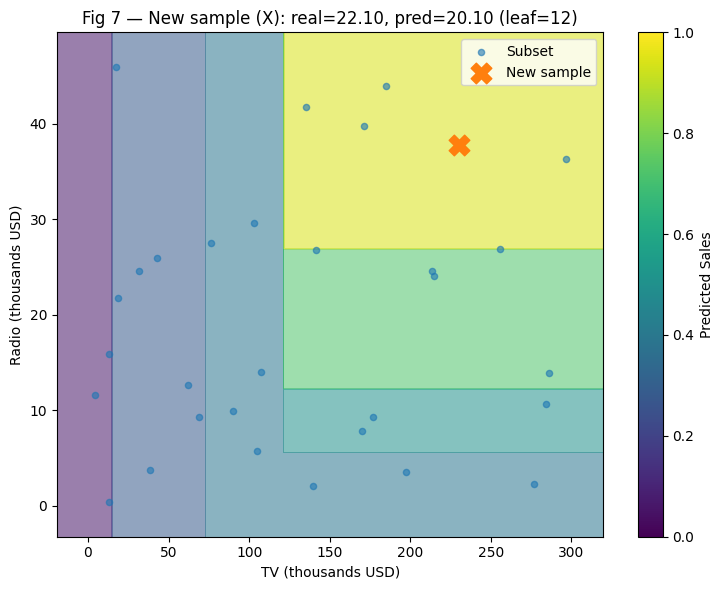

Guardado: fig_tree_advertising_steps_clean/fig7_punto_nuevo_real_vs_pred.png


In [17]:
df_rest = df2.drop(index=idx_s).reset_index(drop=True)

x_new = df_rest[FEATURES].iloc[0].to_numpy().reshape(1, -1)
y_real = float(df_rest[TARGET].iloc[0])
y_pred = float(tree.predict(x_new)[0])
leaf_id = int(tree.apply(x_new)[0])

print("New sample:")
print("x_new =", {FEATURES[0]: float(x_new[0, 0]), FEATURES[1]: float(x_new[0, 1])})
print("y_real =", y_real)
print("y_pred =", y_pred)
print("abs error =", abs(y_pred - y_real))
print("leaf_id =", leaf_id)

plt.figure(figsize=(7.6, 6.0))
plt.contourf(xx, yy, pred_grid, alpha=0.55, cmap=cs.cmap, norm=cs.norm)
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6, label="Subset")
plt.scatter(x_new[:, 0], x_new[:, 1], marker="X", s=220, label="New sample")

plt.xlabel("TV (thousands USD)")
plt.ylabel("Radio (thousands USD)")
plt.title(f"Fig 7 — New sample (X): real={y_real:.2f}, pred={y_pred:.2f} (leaf={leaf_id})")
plt.colorbar(label="Predicted Sales")
plt.legend()
save_and_show("fig7_punto_nuevo_real_vs_pred.png")


## Evaluación sobre el subconjunto

Se realiza una partición train/test sobre el subconjunto bidimensional y se entrena un nuevo árbol con la misma configuración. Las métricas obtenidas permiten cuantificar el desempeño del modelo en un escenario reducido y con mayor variabilidad.

In [18]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)

tree_sub = DecisionTreeRegressor(
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=42
).fit(Xtr, ytr)

pred = tree_sub.predict(Xte)

print("[Subset demo]")
print("MAE :", mean_absolute_error(yte, pred))
print("RMSE:", rmse_compat(yte, pred))
print("R2  :", r2_score(yte, pred))


[Subset demo]
MAE : 2.828125
RMSE: 3.010216227467906
R2  : 0.6310785827176828


## Evaluación sobre el conjunto completo

Se entrena un árbol adicional utilizando todo el dataset (TV, Radio → Sales) y se evalúa mediante una partición train/test. Este experimento permite estimar el rendimiento del modelo en un escenario más representativo y menos dependiente del muestreo reducido.

In [ ]:
X_full = df2[FEATURES].to_numpy()
y_full = df2[TARGET].to_numpy()

Xtr, Xte, ytr, yte = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

tree_full = DecisionTreeRegressor(
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=42
).fit(Xtr, ytr)

pred = tree_full.predict(Xte)

print("[All data]")
print("MAE :", mean_absolute_error(yte, pred))
print("RMSE:", rmse_compat(yte, pred))
print("R2  :", r2_score(yte, pred))


[All data]
MAE : 1.7618336085886563
RMSE: 2.259720948964727
R2  : 0.811202360516786
